In [1]:
import copy
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18

c:\Users\rosha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 1
%aimport helper_functions
import helper_functions as HF

%aimport Constants
from Constants import *

# Constants

In [3]:
DATA_ROOT = Path("./../Dataset Folder/Actual/Concrete Crack Images for Classification")
ARTIFACTS_DIR = Path("artifacts")
PLOTS_DIR = ARTIFACTS_DIR / "plots"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
HF.seed_everything(seed=SEED)

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

torch.set_float32_matmul_precision("high")

GPU: NVIDIA GeForce RTX 3060 Laptop GPU


# Dataset

In [6]:
def index_dataset(data_root: Path) -> pd.DataFrame:
	"""
	Build a tabular index of all image files in the dataset. Each row represents one image, with its file path, class name, and numeric label.
	"""
	records: list[ dict[str, str | int] ] = []

	for class_name, label in CLASS_TO_LABEL.items():
		class_directory = data_root / class_name

		if class_directory.exists() == False:
			raise FileNotFoundError(f"Missing class directory: {class_directory}")

		for path in class_directory.iterdir():
			if path.name == ".gitkeep":
				continue

			assert path.suffix == ".jpg", f"Unexpected file extension: {path}"
			assert path.is_file(follow_symlinks=True), f"Unexpected symlink type: {path}"
			
			if path.is_file(follow_symlinks=True):
				records.append(
					{"path": str(path), "class_name": class_name, "label": label}
					)
	
	if records == []:
		raise ValueError(f"No images found in {data_root}")
	
	return pd.DataFrame.from_records(records)

dataset_df = index_dataset(DATA_ROOT)

In [7]:
def stratified_split(frame: pd.DataFrame,
					 train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO,
					 seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
	"""
	Split the full dataset into train, validation, and test sets while preserving class balance.
	"""
	if np.isclose(train_ratio + val_ratio + TEST_RATIO, 1.0) == False:
		raise ValueError("TRAIN_RATIO + VAL_RATIO + TEST_RATIO must sum to 1")
	
	train_parts: list[pd.DataFrame] = []
	val_parts: list[pd.DataFrame] = []
	test_parts: list[pd.DataFrame] = []

	for label, group in frame.groupby("label", sort=True):
		group = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)
		n_total = len(group)
		n_train = int(n_total * train_ratio)
		n_val = int(n_total * val_ratio)

		train_parts.append( group.iloc[:n_train] )
		val_parts.append( group.iloc[n_train : n_train + n_val] )
		test_parts.append( group.iloc[n_train + n_val :] )
	
	train_df = pd.concat(train_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
	val_df = pd.concat(val_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
	test_df = pd.concat(test_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

	return train_df, val_df, test_df

train_df, val_df, test_df = stratified_split(dataset_df)

# display(train_df, train_df["class_name"].value_counts(), train_df["label"].value_counts(),
# 		val_df, val_df["class_name"].value_counts(), val_df["label"].value_counts(),
# 		test_df, test_df["class_name"].value_counts(), test_df["label"].value_counts(),)

In [8]:
DATASET_MEAN, DATASET_STD = HF.compute_mean_std(frame=train_df, batch_size=BATCH_SIZE, num_workers=0, device=DEVICE)
print("DATASET_MEAN =", DATASET_MEAN)
print("DATASET_STD  =", DATASET_STD)

cuda <class 'torch.device'>
DATASET_MEAN = tensor([0.7193, 0.6988, 0.6661], device='cuda:0', dtype=torch.float64)
DATASET_STD  = tensor([0.1112, 0.1087, 0.1093], device='cuda:0', dtype=torch.float64)


```py
DATASET_MEAN = tensor([0.7193, 0.6988, 0.6661])
DATASET_STD  = tensor([0.1112, 0.1087, 0.1093])
```

In [9]:
def summarize_split(frame: pd.DataFrame, split_name: str) -> dict[str, str | int | float]:
	total = len(frame)
	positive = int( (frame["label"] == 1).sum() )
	negative = int( (frame["label"] == 0).sum() )

	assert positive + negative == total
	assert positive >= 0 and negative >= 0
	assert (0 <= positive / total <= 1) and (0 <= negative / total <= 1)

	return {
		"split": split_name,
		"total": total,
		"negative": negative,
		"positive": positive,
		"positive_rate": positive / total,
	}

split_summary = pd.DataFrame(
	[
		summarize_split(dataset_df, "full_dataset"),
		summarize_split(train_df, "train"),
		summarize_split(val_df, "validation"),
		summarize_split(test_df, "test"),
	]
)

display(split_summary)
del split_summary

,split,total,negative,positive,positive_rate
0,full_dataset,24000,20000,4000,0.166667
1,train,16800,14000,2800,0.166667
2,validation,3600,3000,600,0.166667
3,test,3600,3000,600,0.166667


In [10]:
def save_figure(fig: plt.Figure, filename: str) -> None:
	if not SAVE_PLOTS:
		return
	
	output_path = PLOTS_DIR / filename
	fig.tight_layout()
	fig.savefig(output_path, dpi=160, bbox_inches="tight")
	print(f"Saved figure to: {output_path}")

Saved figure to: artifacts\plots\class_distribution.png


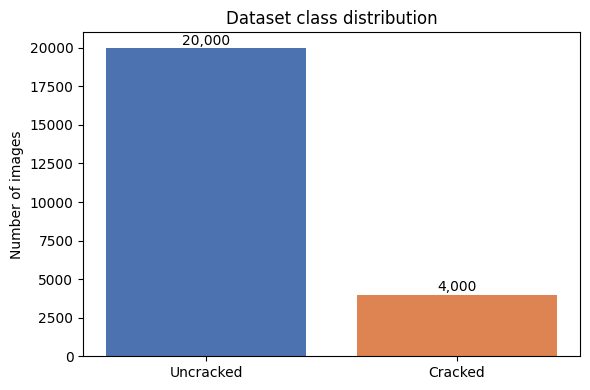

In [11]:
def plot_class_distribution(frame: pd.DataFrame) -> None:
	counts = frame["class_name"].value_counts().reindex(["Negative", "Positive"])
	fig, ax = plt.subplots(figsize=(6, 4))

	ax.bar( ["Uncracked", "Cracked"], counts.values, color=["#4C72B0", "#DD8452"] )
	ax.set_title("Dataset class distribution")
	ax.set_ylabel("Number of images")

	for idx, value in enumerate(counts.values):
		ax.text(idx, value + max(counts.values) * 0.01, f"{value:,}", ha="center")

	save_figure(fig, "class_distribution.png")
	plt.show()

plot_class_distribution(dataset_df)

Saved figure to: artifacts\plots\sample_images.png


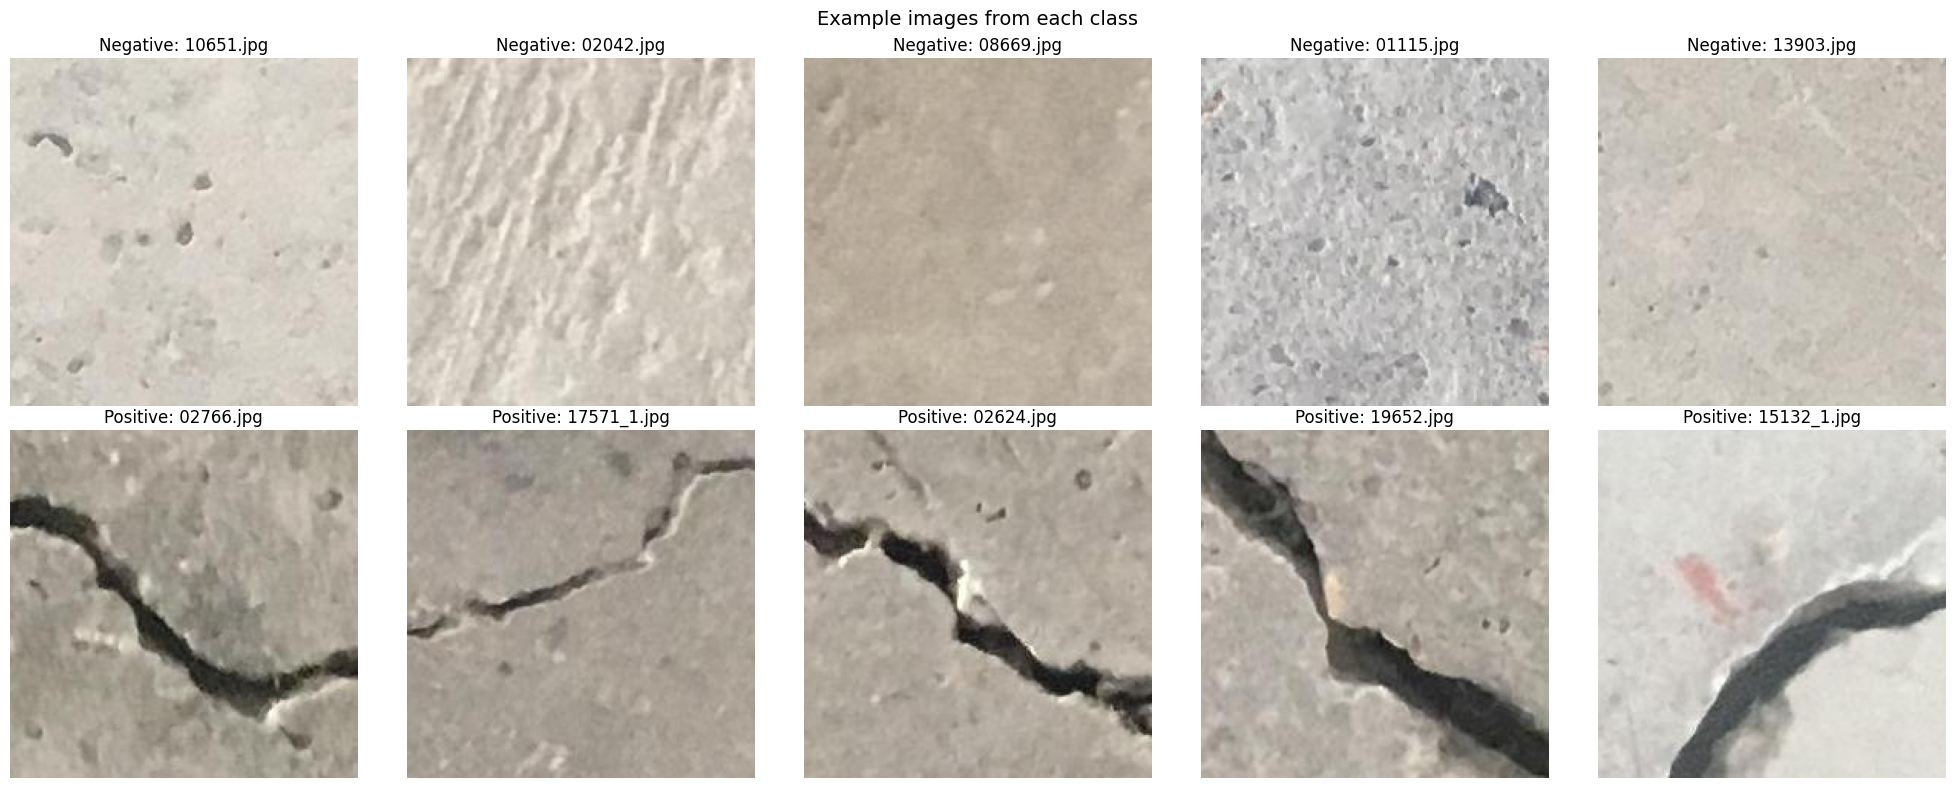

In [12]:
def show_sample_images(frame: pd.DataFrame, samples_per_class: int, seed: int = SEED) -> None:
	fig, axes = plt.subplots(nrows=2, ncols=samples_per_class, 
						  figsize=(4 * samples_per_class, 8))

	for row_idx, class_name in enumerate(["Negative", "Positive"]):
		samples = frame.loc[frame["class_name"] == class_name].sample(n=samples_per_class, random_state=seed).reset_index(drop=True)
		
		for col_idx, (_, row) in enumerate(samples.iterrows()):
			ax = axes[row_idx, col_idx]
			with Image.open(row["path"]) as image:
				ax.imshow(image.convert("RGB"))
			ax.set_title(f"{class_name}: {Path(row['path']).name}")
			ax.axis("off")

	fig.suptitle("Example images from each class", fontsize=14)
	save_figure(fig, "sample_images.png")
	plt.show()

show_sample_images(dataset_df, samples_per_class=5)

# Dataset Class, Transforms, Loaders

In [13]:
train_transform = transforms.Compose(
    [
        transforms.Resize((232, 232)),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(DATASET_MEAN, DATASET_STD),
        transforms.RandomErasing(p=0.20, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(DATASET_MEAN, DATASET_STD),
    ]
)

In [14]:
class ConcreteCrackDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform: transforms.Compose | None = None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.frame.iloc[index]
        
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                tensor: torch.Tensor = self.transform(image) # type: ignore
            else:
                tensor: torch.Tensor = transforms.ToTensor()(pic=image)

        label = torch.tensor(row["label"], dtype=torch.float32)
        return tensor, label

In [15]:
def build_weighted_sampler(frame: pd.DataFrame, seed: int = SEED) -> WeightedRandomSampler:
	"""
	Create a sampler that oversamples minority classes so training batches are more balanced.

	Counts how many samples each label has, assigns larger weight to rarer classes, and creates a reproducible random generator
	"""
	counts = frame["label"].value_counts().sort_index()
	class_weights = {label: 1.0 / count for label, count in counts.items()}
	sample_weights = frame["label"].map(class_weights).to_numpy(dtype=np.float64)
	generator = torch.Generator()
	generator.manual_seed(seed)
	
	return WeightedRandomSampler(
		weights=torch.tensor(sample_weights, dtype=torch.double),
		num_samples=len(sample_weights),
		replacement=True,
		generator=generator,
	)

build_weighted_sampler(dataset_df)

In [16]:
# For Sondre my man

test_df.to_csv(path_or_buf="./../Autoencoder/concrete_test_split.csv")

In [17]:
def build_dataloaders(train_frame: pd.DataFrame, val_frame: pd.DataFrame, test_frame: pd.DataFrame,
					  batch_size: int = BATCH_SIZE, num_workers: int = NUM_WORKERS, use_weighted_sampler: bool = USE_WEIGHTED_SAMPLER) -> tuple[
						  DataLoader[tuple[torch.Tensor, torch.Tensor]], 
						  DataLoader[tuple[torch.Tensor, torch.Tensor]], 
						  DataLoader[tuple[torch.Tensor, torch.Tensor]]]:
	"""
	Create PyTorch `DataLoader` objects for training, validation, and testing.
	"""
	train_dataset = ConcreteCrackDataset(train_frame, transform=train_transform)
	val_dataset = ConcreteCrackDataset(val_frame, transform=eval_transform)
	test_dataset = ConcreteCrackDataset(test_frame, transform=eval_transform)

	sampler = build_weighted_sampler(train_frame) if use_weighted_sampler else None

	train_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]] = DataLoader(
		dataset=train_dataset,
		batch_size=batch_size,
		shuffle=sampler is None,
		sampler=sampler,
		num_workers=num_workers,
		persistent_workers=(num_workers > 0),
		pin_memory=AMP_ENABLED,
	)
	val_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]] = DataLoader(
		dataset=val_dataset,
		batch_size=batch_size,
		shuffle=False,
		num_workers=num_workers,
		persistent_workers=(num_workers > 0),
		pin_memory=AMP_ENABLED,
	)
	test_loader: DataLoader[tuple[torch.Tensor, torch.Tensor]] = DataLoader(
		dataset=test_dataset,
		batch_size=batch_size,
		shuffle=False,
		num_workers=num_workers,
		persistent_workers=(num_workers > 0),
		pin_memory=AMP_ENABLED,
	)
	return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders(train_df, val_df, test_df)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 263
Validation batches: 57
Test batches: 57


# Custom CNN from Scratch

In [18]:
class ConvBNAct(nn.Module):
    """
    Small reusable convolutional block consisting of Conv2D -> BatchNorm -> SiLU
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class SqueezeExcitation(nn.Module):
    """
    Squeeze-and-Excitation block, see https://arxiv.org/abs/1709.01507 & https://medium.com/@tahasamavati/squeeze-and-excitation-explained-387b5981f249

    Lets network learn which channels are important and rescale them adaptively
    """
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(8, channels // reduction)
        
        self.layers = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),            # Squeeze
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.layers(x)

In [19]:
class ResidualBlock(nn.Module):
	"""
	Learns a deeper transformation while keeping a shortcut connection from input to output
	"""
	def __init__(self, in_channels: int, out_channels: int, stride: int = 1, drop_prob: float = 0.0):
		super().__init__()
		self.conv1 = ConvBNAct(in_channels, out_channels, stride=stride)
		self.conv2 = nn.Sequential(
			nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
			nn.BatchNorm2d(out_channels),
		)
		self.se = SqueezeExcitation(out_channels)

		if drop_prob > 0:
			self.dropout = nn.Dropout2d(drop_prob)
		else:
			self.dropout = nn.Identity()
		
		if stride != 1 or in_channels != out_channels:
			self.shortcut = nn.Sequential(
				nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
				nn.BatchNorm2d(out_channels),
			)
		else:
			self.shortcut = nn.Identity()

		self.activation = nn.SiLU(inplace=True)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		residual = self.shortcut(x)
		x = self.conv1(x)
		x = self.dropout(x)
		x = self.conv2(x)
		x = self.se(x)
		x = x + residual
		return self.activation(x)

In [20]:
class CustomCrackCNN(nn.Module):
    """
    The fully custom CNN model for crack classificaiton
    """
    def __init__(self, dropout: float = 0.35):
        super().__init__()
        self.features = nn.Sequential(
            ConvBNAct(3, 32, stride=1),
            ConvBNAct(32, 32, stride=1),
            nn.MaxPool2d(kernel_size=2),
            ResidualBlock(32, 64, stride=2, drop_prob=0.05),
            ResidualBlock(64, 128, stride=2, drop_prob=0.08),
            ResidualBlock(128, 256, stride=2, drop_prob=0.10),
            ResidualBlock(256, 384, stride=2, drop_prob=0.12),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(384),
            nn.Dropout(dropout),
            nn.Linear(384, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

In [21]:
def build_model(model_name: str, dropout: float = 0.35, pretrained: bool = False) -> nn.Module:
    if model_name == "custom_cnn":
        return CustomCrackCNN(dropout=dropout)

    if model_name == "resnet18":
        try:
            weights = ResNet18_Weights.DEFAULT if pretrained else None
            model = resnet18(weights=weights)
        except Exception as exc:
            print(f"Falling back to randomly initialized ResNet18 because pretrained weights were unavailable: {exc}")
            model = resnet18(weights=None)
            
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)
        return model

    raise ValueError(f"Unsupported model_name: {model_name}")

In [22]:
demo_model = build_model("custom_cnn", dropout=BASE_CONFIG["dropout"]).to(DEVICE)
print(demo_model.__class__.__name__)
sum(parameter.numel() for parameter in demo_model.parameters())

CustomCrackCNN


3639049

# Metrics, Training, Checkpoint

In [24]:
def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> tuple[float, np.ndarray, np.ndarray]:
    """
    Evaluate a model using the specified data loader and loss function.

    Returns:
        - Average loss over the dataset
        - Array of true labels
        - Array of predicted probabilities
    """
    model.eval()
    running_loss = 0.0
    labels_buffer: list[np.ndarray] = []
    probs_buffer: list[np.ndarray] = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            running_loss += float(loss.item()) * images.size(0)
            labels_buffer.append(labels.detach().cpu().numpy())
            probs_buffer.append(probs.detach().cpu().numpy())

    labels_array = np.concatenate(labels_buffer)
    probs_array = np.concatenate(probs_buffer)
    average_loss = running_loss / len(loader.dataset)
    
    return average_loss, labels_array, probs_array

In [25]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module, device: torch.device, scaler: torch.amp.GradScaler | None) -> float:
	"""
	Train a model for a single epoch using the specified data loader and optimizer.
	"""
	model.train()
	running_loss = 0.0

	progress_bar = tqdm(loader, leave=False)
	for images, labels in progress_bar:
		images = images.to(device, non_blocking=True)
		labels = labels.to(device, non_blocking=True)

		optimizer.zero_grad(set_to_none=True)
		with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=AMP_ENABLED):
			logits = model(images)
			loss = criterion(logits, labels)

		if (scaler is not None) and AMP_ENABLED:
			scaler.scale(loss).backward()
			scaler.unscale_(optimizer)
			torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
			scaler.step(optimizer)
			scaler.update()
		else:
			loss.backward()
			torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
			optimizer.step()

		running_loss += float(loss.item()) * images.size(0)
		progress_bar.set_description(f"train_loss={loss.item():.4f}")

	return running_loss / len(loader.dataset)

In [26]:
def build_criterion(train_frame: pd.DataFrame, use_weighted_sampler: bool, device: torch.device) -> nn.Module:
    if use_weighted_sampler:
        return nn.BCEWithLogitsLoss()

    negative_count = int((train_frame["label"] == 0).sum())
    positive_count = int((train_frame["label"] == 1).sum())
    pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=device)
    
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [27]:
def fit_model(model: nn.Module, 
			  train_loader: DataLoader, val_loader: DataLoader, train_frame: pd.DataFrame, 
			  config: dict, num_epochs: int, patience: int, experiment_name: str) -> tuple[nn.Module, pd.DataFrame, dict[str, int | float], float]:
	"""
	Full training loop
	"""
	criterion = build_criterion(train_frame=train_frame, use_weighted_sampler=config["use_weighted_sampler"], device=DEVICE)

	optimizer = torch.optim.AdamW(params=model.parameters(), lr=config["learning_rate"],weight_decay=config["weight_decay"])

	scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="max", factor=0.5, patience=1)

	scaler = torch.amp.GradScaler(device="cuda", enabled=AMP_ENABLED) if AMP_ENABLED else None

	best_metric = float("-inf")
	best_state = copy.deepcopy(model.state_dict())
	best_threshold = 0.5
	best_val_metrics: dict[str, int | float] = {}
	epochs_without_improvement = 0
	history_rows: list[dict] = []

	for epoch in range(1, num_epochs + 1):
		start_time = time.time()

		train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
		val_loss, val_labels, val_probs = evaluate_model(model, val_loader, criterion, DEVICE)
		val_threshold, val_metrics = HF.select_best_threshold(val_labels, val_probs, metric_name="f1")

		scheduler.step(val_metrics["f1"])
		epoch_time = time.time() - start_time

		row = {
			"epoch": epoch,
			"train_loss": train_loss,
			"val_loss": val_loss,
			"val_threshold": val_threshold,
			"val_accuracy": val_metrics["accuracy"],
			"val_precision": val_metrics["precision"],
			"val_recall": val_metrics["recall"],
			"val_f1": val_metrics["f1"],
			"val_balanced_accuracy": val_metrics["balanced_accuracy"],
			"val_auroc": val_metrics["auroc"],
			"val_average_precision": val_metrics["average_precision"],
			"lr": optimizer.param_groups[0]["lr"],
			"epoch_seconds": epoch_time,
		}
		history_rows.append(row)

		print(
			f"[{experiment_name}] epoch {epoch:02d}/{num_epochs} | "
			f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
			f"val_f1={val_metrics['f1']:.4f} | val_recall={val_metrics['recall']:.4f} | "
			f"threshold={val_threshold:.2f}"
		)

		if val_metrics["f1"] > best_metric:
			best_metric = float(val_metrics["f1"])
			best_state = copy.deepcopy(model.state_dict())
			best_threshold = float(val_threshold)
			best_val_metrics = val_metrics
			epochs_without_improvement = 0
		else:
			epochs_without_improvement += 1

		if epochs_without_improvement >= patience:
			print(f"Early stopping triggered after epoch {epoch}.")
			break

	model.load_state_dict(best_state)
	history_df = pd.DataFrame(history_rows)

	return model, history_df, best_val_metrics, best_threshold

In [28]:
def plot_training_history(history_df: pd.DataFrame, title: str) -> None:
	"""
	Visualize how trianing evolved across epochs
	"""
	fig, axes = plt.subplots(1, 3, figsize=(18, 4))


	"""			Loss Curves			"""
	axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
	axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
	axes[0].set_title("Loss curves")
	axes[0].set_xlabel("Epoch")
	axes[0].legend()

	"""			Validation Metrics			"""
	axes[1].plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Validation F1")
	axes[1].plot(history_df["epoch"], history_df["val_recall"], marker="o", label="Validation recall")
	axes[1].plot(
		history_df["epoch"],
		history_df["val_balanced_accuracy"],
		marker="o",
		label="Validation balanced accuracy",
	)
	axes[1].set_title("Minority-focused validation metrics")
	axes[1].set_xlabel("Epoch")
	axes[1].legend()

	"""			Learning Rate & Threshold			"""
	axes[2].plot(history_df["epoch"], history_df["lr"], marker="o", label="Learning rate")
	axes[2].plot(history_df["epoch"], history_df["val_threshold"], marker="o", label="Best threshold")
	axes[2].set_title("Scheduler / threshold evolution")
	axes[2].set_xlabel("Epoch")
	axes[2].legend()

	fig.suptitle(title, fontsize=14)
	save_figure(fig, "training_history.png")
	plt.show()

In [29]:
def plot_confusion_matrix(metrics: dict, title: str) -> None:
	"""
	Display a confusion matrix as a colored heatmap.
	"""
	matrix: np.ndarray = np.array( [[metrics["tn"], metrics["fp"]], 
								 [metrics["fn"], metrics["tp"]]], 
								 dtype=np.int64 )
	
	fig, ax = plt.subplots(figsize=(5, 4))
	image = ax.imshow(matrix, cmap="Blues")
	ax.set_xticks([0, 1], labels=["Predicted negative", "Predicted positive"])
	ax.set_yticks([0, 1], labels=["Actual negative", "Actual positive"])
	ax.set_title(title)

	for i in range(matrix.shape[0]):
		for j in range(matrix.shape[1]):
			ax.text(j, i, matrix[i, j], ha="center", va="center", color="black", fontsize=12)

	fig.colorbar(image, ax=ax)
	save_figure(fig, "confusion_matrix.png")
	plt.show()

In [30]:
def plot_roc_and_pr_curves(labels: np.ndarray, probs: np.ndarray, title_prefix: str) -> None:
	"""
	Plot ROC and PR curves for a binary classification task.
	"""
	roc_fpr, roc_tpr = HF.roc_curve_points(labels, probs)
	pr_recall, pr_precision = HF.pr_curve_points(labels, probs)

	fig, axes = plt.subplots(1, 2, figsize=(12, 4))

	axes[0].plot(roc_fpr, roc_tpr, label="ROC curve")
	axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
	axes[0].set_title(f"{title_prefix} ROC")
	axes[0].set_xlabel("False positive rate")
	axes[0].set_ylabel("True positive rate")
	axes[0].legend()

	axes[1].plot(pr_recall, pr_precision, label="PR curve")
	axes[1].set_title(f"{title_prefix} Precision-Recall")
	axes[1].set_xlabel("Recall")
	axes[1].set_ylabel("Precision")
	axes[1].legend()

	save_figure(fig, "roc_pr_curves.png")
	plt.show()

# Hyperparameter Search

In [31]:
tuning_results = pd.DataFrame()
selected_config = BASE_CONFIG.copy()

In [32]:
def stratified_subsample(frame: pd.DataFrame, fraction: float, seed: int = SEED) -> pd.DataFrame:
	"""
	Take a smaller subset of a dataset while preserving class proportions.
	"""
	if fraction >= 1.0:
		return frame.copy().reset_index(drop=True)

	sampled_parts: list[pd.DataFrame] = []
	for label, group in frame.groupby("label", sort=True):
		n_samples = int( round(len(group) * fraction) )
		sampled_parts.append(group.sample(n=n_samples, random_state=seed))

	return pd.concat(sampled_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

In [33]:
if RUN_HYPERPARAM_SEARCH:
    tuning_train_df = stratified_subsample(train_df, TUNING_TRAIN_FRACTION, seed=SEED)
    tuning_val_df = stratified_subsample(val_df, TUNING_VAL_FRACTION, seed=SEED)

    search_rows: list[dict] = []
    for index, candidate in enumerate(HYPERPARAM_CANDIDATES, start=1):
        candidate_config = BASE_CONFIG | candidate
        experiment_name = f"tune_{index}_{candidate_config['model_name']}"
        tune_train_loader, tune_val_loader, _ = build_dataloaders(
            tuning_train_df,
            tuning_val_df,
            tuning_val_df,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            use_weighted_sampler=candidate_config["use_weighted_sampler"],
        )

        tuning_model = build_model(
            candidate_config["model_name"],
            dropout=candidate_config["dropout"],
            pretrained=False,
        ).to(DEVICE)

        tuning_model, tuning_history, tuning_val_metrics, tuning_threshold = fit_model(
            tuning_model,
            tune_train_loader,
            tune_val_loader,
            tuning_train_df,
            candidate_config,
            num_epochs=TUNING_EPOCHS,
            patience=2,
            experiment_name=experiment_name,
        )

        search_rows.append(
            {
                "candidate_id": index,
                "learning_rate": candidate_config["learning_rate"],
                "weight_decay": candidate_config["weight_decay"],
                "dropout": candidate_config["dropout"],
                "use_weighted_sampler": candidate_config["use_weighted_sampler"],
                "best_val_f1": tuning_val_metrics["f1"],
                "best_val_recall": tuning_val_metrics["recall"],
                "best_val_precision": tuning_val_metrics["precision"],
                "best_val_threshold": tuning_threshold,
            }
        )

    tuning_results = pd.DataFrame(search_rows).sort_values("best_val_f1", ascending=False).reset_index(drop=True)
    
    best_row = tuning_results.iloc[0].to_dict()
    selected_config = BASE_CONFIG | {
        "learning_rate": float(best_row["learning_rate"]),
        "weight_decay": float(best_row["weight_decay"]),
        "dropout": float(best_row["dropout"]),
        "use_weighted_sampler": bool(best_row["use_weighted_sampler"]),
    }

[tune_1_custom_cnn] epoch 01/3 | train_loss=0.0842 | val_loss=0.0168 | val_f1=0.9922 | val_recall=0.9956 | threshold=0.60


[tune_1_custom_cnn] epoch 02/3 | train_loss=0.0308 | val_loss=0.0231 | val_f1=0.9934 | val_recall=0.9978 | threshold=0.93


[tune_1_custom_cnn] epoch 03/3 | train_loss=0.0215 | val_loss=0.0256 | val_f1=0.9912 | val_recall=0.9978 | threshold=0.94


[tune_2_custom_cnn] epoch 01/3 | train_loss=0.0912 | val_loss=0.0093 | val_f1=0.9978 | val_recall=0.9956 | threshold=0.70


[tune_2_custom_cnn] epoch 02/3 | train_loss=0.0287 | val_loss=0.0348 | val_f1=0.9967 | val_recall=0.9978 | threshold=0.93


[tune_2_custom_cnn] epoch 03/3 | train_loss=0.0211 | val_loss=0.0492 | val_f1=0.9836 | val_recall=0.9978 | threshold=0.95
Early stopping triggered after epoch 3.


[tune_3_custom_cnn] epoch 01/3 | train_loss=0.0786 | val_loss=0.0130 | val_f1=0.9956 | val_recall=0.9956 | threshold=0.64


[tune_3_custom_cnn] epoch 02/3 | train_loss=0.0324 | val_loss=0.0286 | val_f1=0.9901 | val_recall=0.9978 | threshold=0.77


[tune_3_custom_cnn] epoch 03/3 | train_loss=0.0228 | val_loss=0.0395 | val_f1=0.9923 | val_recall=1.0000 | threshold=0.95
Early stopping triggered after epoch 3.


In [34]:
print("Selected configuration:")
print(json.dumps(selected_config, indent=2))
tuning_results

Selected configuration:
{
  "model_name": "custom_cnn",
  "learning_rate": 0.0007,
  "weight_decay": 0.0001,
  "dropout": 0.35,
  "use_weighted_sampler": true
}


,candidate_id,learning_rate,weight_decay,dropout,use_weighted_sampler,best_val_f1,best_val_recall,best_val_precision,best_val_threshold
0,2,0.0007,0.0001,0.35,True,0.997773,0.995556,1.000000,0.705
1,3,0.0005,0.0005,0.45,True,0.995556,0.995556,0.995556,0.635
2,1,0.0010,0.0001,0.25,True,0.993363,0.997778,0.988987,0.935


# Train model from scratch

In [35]:
experiment_name = selected_config["model_name"]
main_model = build_model(model_name=selected_config["model_name"], dropout=selected_config["dropout"], pretrained=False).to(DEVICE)

train_loader, val_loader, test_loader = build_dataloaders(
    train_df,
    val_df,
    test_df,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    use_weighted_sampler=selected_config["use_weighted_sampler"],
)

main_model, history_df, best_val_metrics, best_threshold = fit_model(
    main_model,
    train_loader,
    val_loader,
    train_df,
    selected_config,
    num_epochs=NUM_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    experiment_name=experiment_name,
)

final_criterion = build_criterion(train_df, use_weighted_sampler=selected_config["use_weighted_sampler"], device=DEVICE)
test_loss, test_labels, test_probs = evaluate_model(main_model, test_loader, final_criterion, DEVICE)
test_metrics = HF.compute_binary_metrics(test_labels, test_probs, threshold=best_threshold)
test_metrics["loss"] = float(test_loss)

"Simple baseline for comparison since the model should clearly be better than an always-negative predictor"
majority_baseline_metrics = HF.compute_binary_metrics(
    test_labels,
    probs=np.zeros_like(test_probs),
    threshold=0.5,
)

[custom_cnn] epoch 01/15 | train_loss=0.0724 | val_loss=0.0115 | val_f1=0.9917 | val_recall=0.9917 | threshold=0.29


[custom_cnn] epoch 02/15 | train_loss=0.0247 | val_loss=0.0139 | val_f1=0.9933 | val_recall=0.9883 | threshold=0.76


[custom_cnn] epoch 03/15 | train_loss=0.0204 | val_loss=0.0050 | val_f1=0.9983 | val_recall=0.9967 | threshold=0.47


[custom_cnn] epoch 04/15 | train_loss=0.0159 | val_loss=0.0826 | val_f1=0.9691 | val_recall=0.9933 | threshold=0.94


[custom_cnn] epoch 05/15 | train_loss=0.0150 | val_loss=0.0034 | val_f1=0.9958 | val_recall=0.9983 | threshold=0.15


...

[custom_cnn] epoch 10/15 | train_loss=0.0037 | val_loss=0.0024 | val_f1=1.0000 | val_recall=1.0000 | threshold=0.82


[custom_cnn] epoch 11/15 | train_loss=0.0077 | val_loss=0.0017 | val_f1=1.0000 | val_recall=1.0000 | threshold=0.75


[custom_cnn] epoch 12/15 | train_loss=0.0057 | val_loss=0.0018 | val_f1=0.9992 | val_recall=0.9983 | threshold=0.81


[custom_cnn] epoch 13/15 | train_loss=0.0052 | val_loss=0.0010 | val_f1=1.0000 | val_recall=1.0000 | threshold=0.61


[custom_cnn] epoch 14/15 | train_loss=0.0058 | val_loss=0.0019 | val_f1=1.0000 | val_recall=1.0000 | threshold=0.85
Early stopping triggered after epoch 14.


In [36]:
checkpoint_payload: dict[str, object] = {
    "model_name": selected_config["model_name"],
    "model_kwargs": {
        "dropout": selected_config["dropout"],
        "pretrained": False,
    },
    "config": selected_config,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "best_threshold": best_threshold,
    "best_val_metrics": best_val_metrics,
    "test_metrics": test_metrics,
    "history": history_df.to_dict(orient="records"),
    "state_dict": main_model.state_dict(),
    "splits": {
        "train": train_df.to_dict(orient="records"),
        "validation": val_df.to_dict(orient="records"),
        "test": test_df.to_dict(orient="records"),
    },
}

In [37]:
checkpoint_path = ARTIFACTS_DIR / f"{experiment_name}_best.pt"
history_path = ARTIFACTS_DIR / f"{experiment_name}_history.csv"
metrics_path = ARTIFACTS_DIR / f"{experiment_name}_test_metrics.json"

torch.save(checkpoint_payload, checkpoint_path)
history_df.to_csv(history_path, index=False)
metrics_path.write_text(json.dumps(test_metrics, indent=2))

print(f"Checkpoint saved to: {checkpoint_path}")
print(f"History saved to: {history_path}")
print(f"Metrics saved to: {metrics_path}")

Checkpoint saved to: artifacts\custom_cnn_best.pt
History saved to: artifacts\custom_cnn_history.csv
Metrics saved to: artifacts\custom_cnn_test_metrics.json


In [38]:
pd.DataFrame(
    [
        {"model": "Majority class baseline", **majority_baseline_metrics},
        {"model": "Custom CNN from scratch", **test_metrics},
    ] # Metric dictionaries unpacked into columns
)[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
        "auroc",
        "average_precision",
    ] # Specific columns selected
]

,model,accuracy,precision,recall,f1,balanced_accuracy,auroc,average_precision
0,Majority class baseline,0.833333,0.000000,0.000000,0.000000,0.500000,0.500000,0.158750
1,Custom CNN from scratch,0.999167,0.998331,0.996667,0.997498,0.998167,0.999974,0.999869


Validation metrics at the selected checkpoint:
{
  "threshold": 0.82,
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "specificity": 1.0,
  "f1": 1.0,
  "balanced_accuracy": 1.0,
  "auroc": 1.0,
  "average_precision": 1.0,
  "tp": 600,
  "tn": 3000,
  "fp": 0,
  "fn": 0
}

Test metrics:
{
  "threshold": 0.82,
  "accuracy": 0.9991666666666666,
  "precision": 0.998330550918197,
  "recall": 0.9966666666666667,
  "specificity": 0.9996666666666667,
  "f1": 0.9974979149291077,
  "balanced_accuracy": 0.9981666666666666,
  "auroc": 0.9999741666666667,
  "average_precision": 0.9998689594002448,
  "tp": 598,
  "tn": 2999,
  "fp": 1,
  "fn": 2,
  "loss": 0.003951216086279601
}
Saved figure to: artifacts\plots\training_history.png


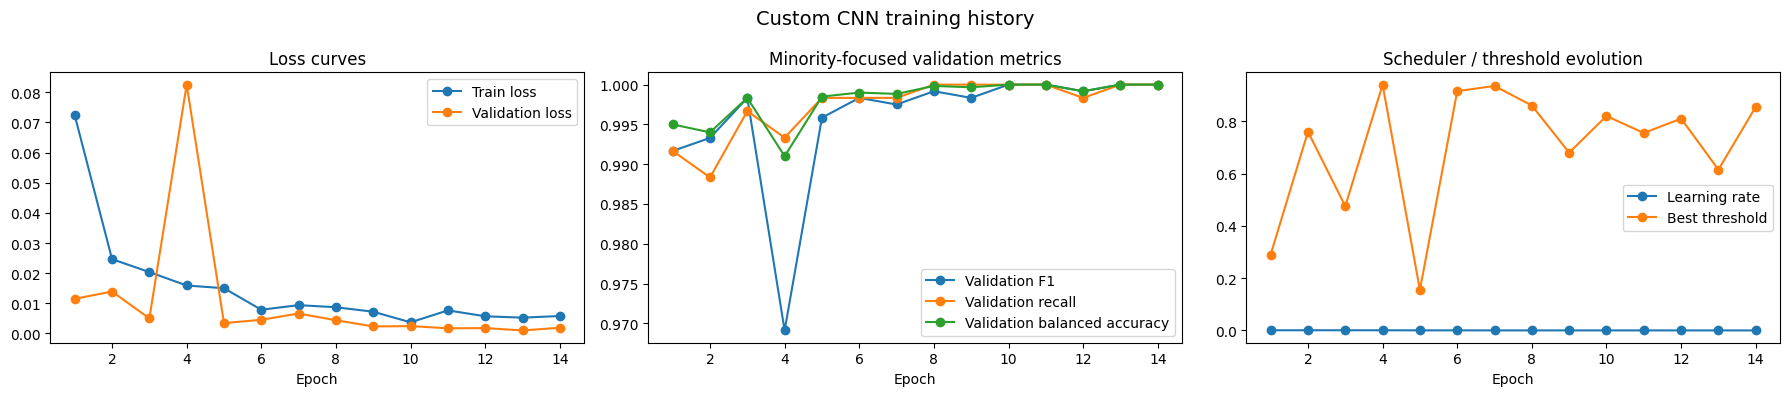

Saved figure to: artifacts\plots\confusion_matrix.png


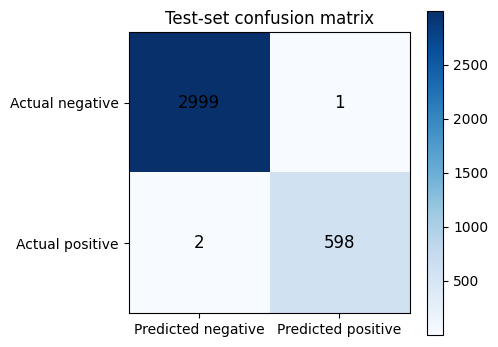

Saved figure to: artifacts\plots\roc_pr_curves.png


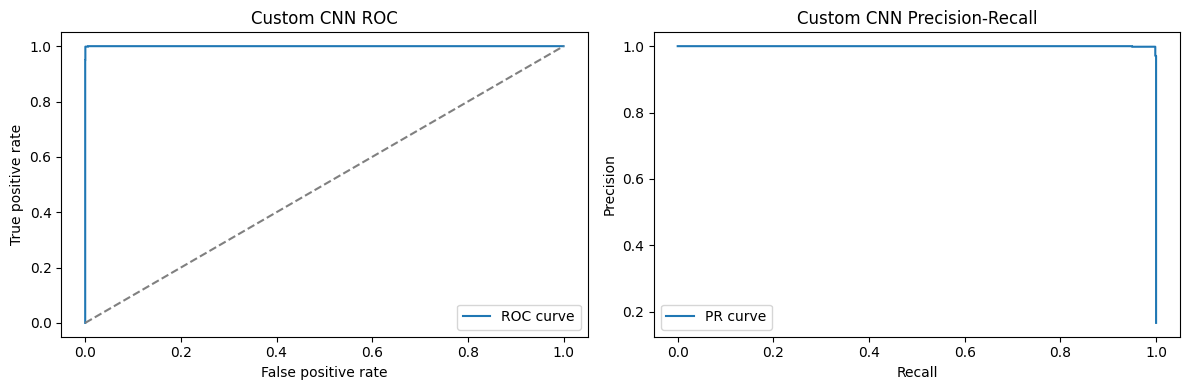

In [39]:
print("Validation metrics at the selected checkpoint:")
print(json.dumps(best_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))

plot_training_history(history_df, title="Custom CNN training history")
plot_confusion_matrix(test_metrics, title="Test-set confusion matrix")
plot_roc_and_pr_curves(test_labels, test_probs, title_prefix="Custom CNN")


# Failure-case analysis

In [40]:
def show_misclassified_examples(frame: pd.DataFrame, probs: np.ndarray, threshold: float, error_type: str, top_k: int = 10) -> None:
	"""
	Display the most informative misclassified images
	"""
	
	labels = frame["label"].to_numpy(dtype=np.int64)
	preds = (probs >= threshold).astype(np.int64)

	if error_type == "false_negative":
		mask = (labels == 1) & (preds == 0)
		sort_key = probs
		title = "Highest-confidence false negatives"
		ascending = True
	elif error_type == "false_positive":
		mask = (labels == 0) & (preds == 1)
		sort_key = probs
		title = "Highest-confidence false positives"
		ascending = False
	else:
		raise ValueError("error_type must be either 'false_negative' or 'false_positive'.")

	subset = frame.loc[mask].copy()
	if subset.empty:
		print(f"No {error_type.replace('_', ' ')} examples found.")
		return

	subset["probability_cracked"] = sort_key[mask]
	subset = subset.sort_values("probability_cracked", ascending=ascending).head(top_k).reset_index(drop=True)

	fig, axes = plt.subplots(1, len(subset), figsize=(4 * len(subset), 4))
	if len(subset) == 1:
		axes = [axes]

	for ax, (_, row) in zip(axes, subset.iterrows()):
		with Image.open(row["path"]) as image:
			ax.imshow(image.convert("RGB"))
		ax.set_title(
			f"{Path(row['path']).name}\nlabel={DISPLAY_NAMES[row['label']]}\np={row['probability_cracked']:.3f}"
		)
		ax.axis("off")

	fig.suptitle(title, fontsize=14)
	save_figure(fig, f"{error_type}_examples.png")
	plt.show()

Saved figure to: artifacts\plots\false_negative_examples.png


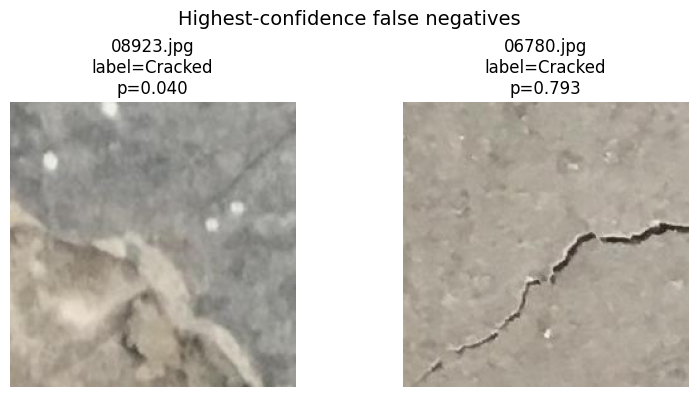

Saved figure to: artifacts\plots\false_positive_examples.png


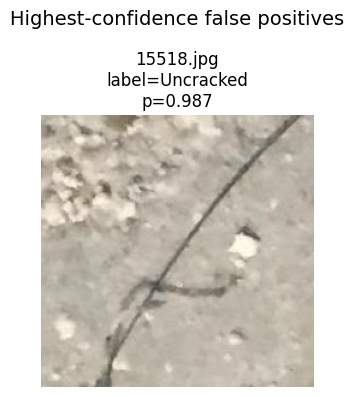

In [41]:
show_misclassified_examples(test_df, test_probs, threshold=best_threshold, error_type="false_negative", top_k=10)
show_misclassified_examples(test_df, test_probs, threshold=best_threshold, error_type="false_positive", top_k=10)

# Reload saved checkpoint

Metrics stored in checkpoint:
{
  "threshold": 0.82,
  "accuracy": 0.9991666666666666,
  "precision": 0.998330550918197,
  "recall": 0.9966666666666667,
  "specificity": 0.9996666666666667,
  "f1": 0.9974979149291077,
  "balanced_accuracy": 0.9981666666666666,
  "auroc": 0.9999741666666667,
  "average_precision": 0.9998689594002448,
  "tp": 598,
  "tn": 2999,
  "fp": 1,
  "fn": 2,
  "loss": 0.003951216086279601
}

Metrics recomputed after reloading:
{
  "threshold": 0.82,
  "accuracy": 0.9991666666666666,
  "precision": 0.998330550918197,
  "recall": 0.9966666666666667,
  "specificity": 0.9996666666666667,
  "f1": 0.9974979149291077,
  "balanced_accuracy": 0.9981666666666666,
  "auroc": 0.9999741666666667,
  "average_precision": 0.9998689594002448,
  "tp": 598,
  "tn": 2999,
  "fp": 1,
  "fn": 2,
  "loss": 0.003951216086279601
}
Saved figure to: artifacts\plots\training_history.png


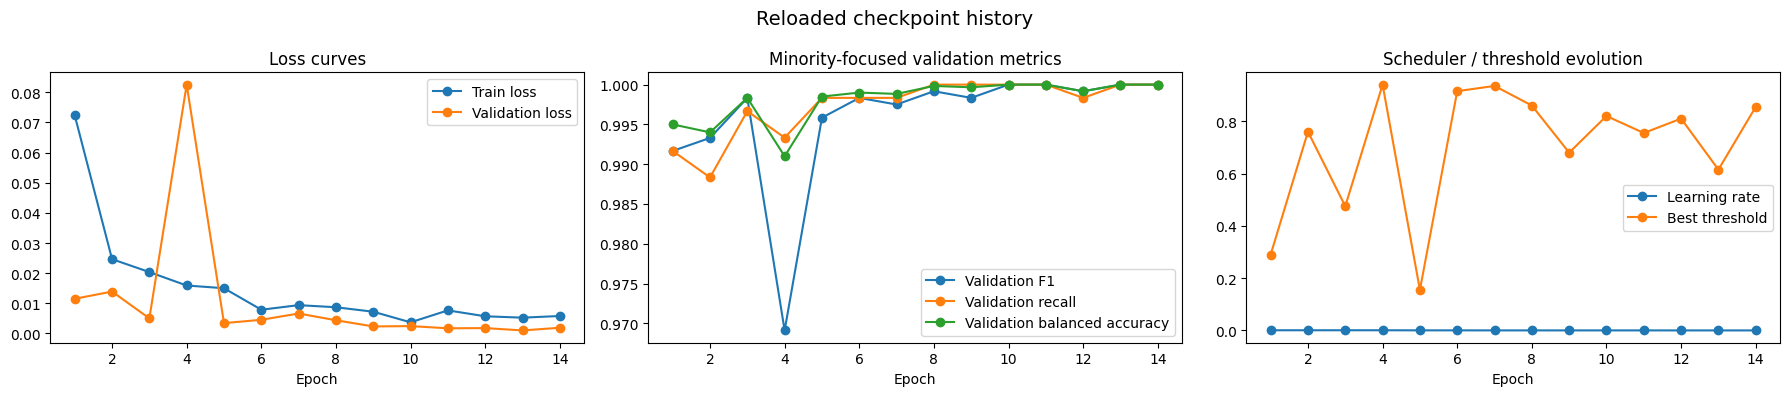

In [42]:
reloaded_checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

reloaded_model = build_model(
    reloaded_checkpoint["model_name"],
    dropout=reloaded_checkpoint["model_kwargs"]["dropout"],
    pretrained=reloaded_checkpoint["model_kwargs"]["pretrained"],
).to(DEVICE)

reloaded_model.load_state_dict(reloaded_checkpoint["state_dict"])
reloaded_threshold = float(reloaded_checkpoint["best_threshold"])

reloaded_train_df = pd.DataFrame(reloaded_checkpoint["splits"]["train"])
reloaded_val_df = pd.DataFrame(reloaded_checkpoint["splits"]["validation"])
reloaded_test_df = pd.DataFrame(reloaded_checkpoint["splits"]["test"])
reloaded_history_df = pd.DataFrame(reloaded_checkpoint["history"])

_, _, reloaded_test_loader = build_dataloaders(
    reloaded_train_df,
    reloaded_val_df,
    reloaded_test_df,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    use_weighted_sampler=reloaded_checkpoint["config"]["use_weighted_sampler"],
)

reloaded_criterion = build_criterion(
    reloaded_train_df,
    use_weighted_sampler=reloaded_checkpoint["config"]["use_weighted_sampler"],
    device=DEVICE,
)
reloaded_test_loss, reloaded_test_labels, reloaded_test_probs = evaluate_model(
    reloaded_model,
    reloaded_test_loader,
    reloaded_criterion,
    DEVICE,
)
reloaded_test_metrics = HF.compute_binary_metrics(
    reloaded_test_labels,
    reloaded_test_probs,
    threshold=reloaded_threshold,
)
reloaded_test_metrics["loss"] = float(reloaded_test_loss)

print("Metrics stored in checkpoint:")
print(json.dumps(reloaded_checkpoint["test_metrics"], indent=2))
print("\nMetrics recomputed after reloading:")
print(json.dumps(reloaded_test_metrics, indent=2))

plot_training_history(reloaded_history_df, title="Reloaded checkpoint history")
